### Logistic_Regression

### Step 1: Import Necessary Libraries
### First, we need to import the libraries required for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Step 2: Load the Titanic Dataset

In [3]:
# Load the dataset
titanic_data = pd.read_csv(r"C:\Users\DELL XPS\Desktop\AI & ML\Data\titanic.csv")

# Display the first few rows of the dataset
print(titanic_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Step 3: Data Preprocessing
#### We need to preprocess the data to handle missing values and convert categorical variables into numerical ones.

In [4]:
# Handling missing values
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)
titanic_data['Fare'].fillna(titanic_data['Fare'].median(), inplace=True)

# Dropping unnecessary columns
titanic_data.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# Converting categorical variables into numerical ones
titanic_data = pd.get_dummies(titanic_data, columns=['Sex', 'Embarked'], drop_first=True)

C:\Users\DELL XPS\AppData\Local\Temp\ipykernel_15680\2228131424.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)
C:\Users\DELL XPS\AppData\Local\Temp\ipykernel_15680\2228131424.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

### Step 4: Split the Data into Training and Testing Sets
#### We split the data into training and testing sets to evaluate the performance of our model.

In [5]:
# Define features and target variable
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 5: Train the Logistic Regression Model
#### We train the logistic regression model on the training data.


In [6]:
# Initialize the logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Train the model
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Step 6: Make Predictions
#### We use the trained model to make predictions on the testing data.

In [7]:
# Make predictions
y_pred = logreg.predict(X_test)

### Step 7: Evaluate the Model
#### We evaluate the model using accuracy, confusion matrix, and classification report.

In [8]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.8100558659217877
Confusion Matrix:
[[90 15]
 [19 55]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### Explanation of Each Step:
- Import Necessary Libraries: We import libraries for data manipulation (pandas, numpy), visualization (seaborn, matplotlib), and machine learning (sklearn).

- Load the Titanic Dataset: We load the Titanic dataset into a pandas dataframe and display the first few rows.

### Data Preprocessing:

- Handle missing values by filling them with median or mode.

- Drop unnecessary columns that do not contribute to the prediction.

- Convert categorical variables (e.g., Sex, Embarked) into numerical ones using one-hot encoding.

- Split the Data: We define the features (X) and target variable (y) and split the data into training and testing sets using train_test_split.

- Train the Logistic Regression Model: We initialize and train the logistic regression model on the training data.

- Make Predictions: We use the trained model to make predictions on the testing data.

- Evaluate the Model: We calculate the accuracy of the model, generate a confusion matrix, and create a classification report to evaluate the model's performance.

### Step 8: Visualize the Data and Model Performance
- Now, let's create some plots to visualize the data and the model's performance.

##### 8.1 Plotting the Distribution of Age and Survival

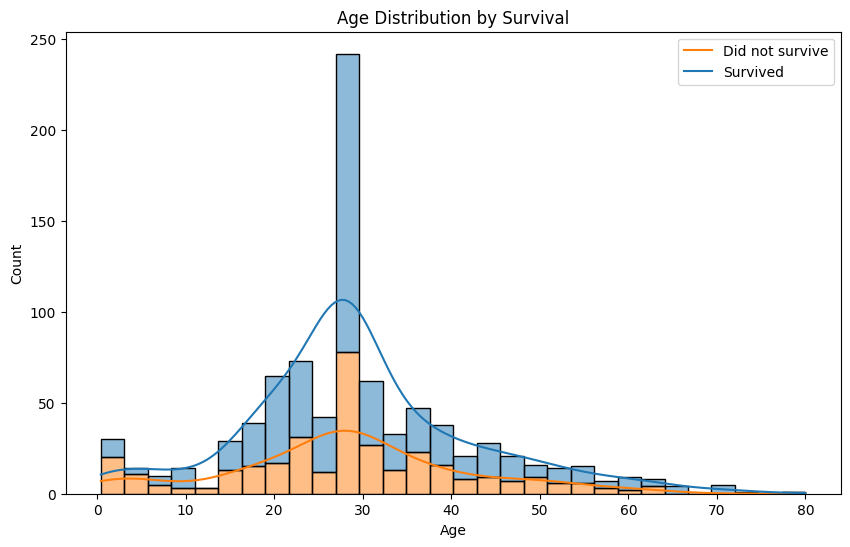

In [9]:
# Plotting the distribution of age and survival
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic_data, x='Age', hue='Survived', multiple='stack', kde=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Did not survive', 'Survived'])
plt.show()

### 8.2 Plotting the Confusion Matrix

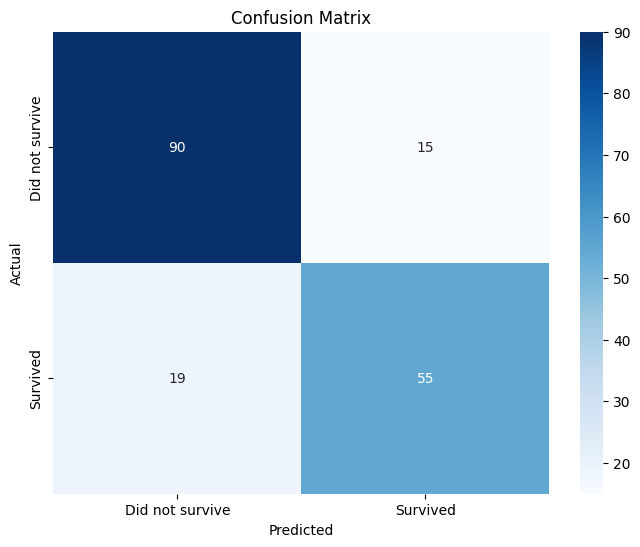

In [10]:
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Did not survive', 'Survived'], yticklabels=['Did not survive', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8.3 Plotting the Feature Importance

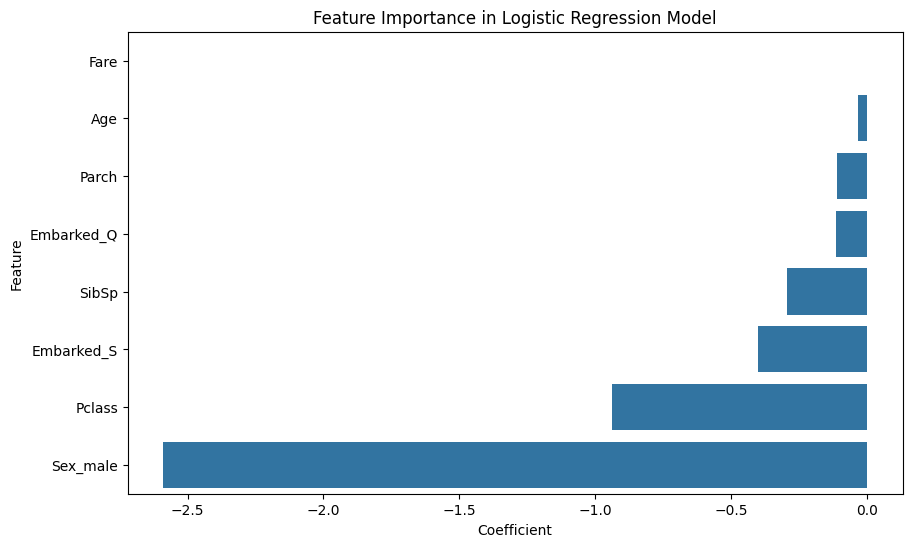

In [11]:
# Plotting the feature importance
feature_importance = pd.Series(logreg.coef_[0], index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Feature Importance in Logistic Regression Model')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

### Explanation of Each Plot:
- Age Distribution by Survival:

- This plot shows the distribution of passengers' ages, with different colors representing whether they survived or not. It helps visualize the relationship between age and survival.

### Confusion Matrix:

- This heatmap shows the confusion matrix, with the actual labels on the y-axis and the predicted labels on the x-axis. It helps understand how well the model performs in terms of true positives, true negatives, false positives, and false negatives.

- Feature Importance in Logistic Regression Model:

- This bar plot shows the importance of each feature in the logistic regression model. The coefficients of the model indicate the contribution of each feature to the prediction of survival. Features with higher absolute coefficients have a stronger influence on the prediction.